In [4]:
import random
import numpy as np
random.seed(42)
np.random.seed(42)

Generate Python code for read

In [5]:
from tensorflow.keras.datasets import mnist, cifar10
import numpy as np

(x_raw, y_raw), (x_test_raw, y_test)= mnist.load_data()

val_size = int(x_raw.shape[0] * 0.3)
rng = np.random.default_rng(42)  # seed for reproducibility
idx = np.arange(x_raw.shape[0])
rng.shuffle(idx)

val_idx = idx[:val_size]
train_idx = idx[val_size:]

(x_train_raw, y_train), (x_val_raw, y_val) = (x_raw[train_idx], y_raw[train_idx]), (x_raw[val_idx], y_raw[val_idx])



import matplotlib.pyplot as plt
import numpy as np
    
x_train, x_test, x_val= x_train_raw/255.0, x_test_raw/255.0, x_val_raw/255.0



In [87]:
import tensorflow as tf
from tensorflow.keras import layers, models
model = models.Sequential([
    layers.Input(shape = (28,28,1)),
    #1
    layers.Conv2D(filters=16, kernel_size = (3,3)),
    layers.BatchNormalization(),
    layers.Activation('relu'),

    #2
    layers.MaxPooling2D((2,2)),

    #3
    layers.Conv2D(filters=32, kernel_size=(3,3)),
    layers.BatchNormalization(),
    layers.Activation("relu"),

    #4
    layers.MaxPooling2D((2,2)),

    #5
    layers.Flatten(),
    layers.Dense(128, activation = "relu"),
    layers.Dropout(0.4),

    #6
    layers.Dense(10, activation = "softmax")
])

model.compile(optimizer = "adam", loss = "sparse_categorical_crossentropy", metrics = ["accuracy"]) #Is the loss and metrics correct?
fitted = model.fit(x_train_extra, y_train, epochs = 5, batch_size = 64, validation_data = (x_val_extra, y_val))

test_loss, test_acc = model.evaluate(x_test_extra, y_test)
print("Test accuracy: ", test_acc)

Epoch 1/5
657/657 ━━━━━━━━━━━━━━━━━━━━ 26s 33ms/step - accuracy: 0.9158 - loss: 0.2758 - val_accuracy: 0.9788 - val_loss: 0.0694
Epoch 2/5
657/657 ━━━━━━━━━━━━━━━━━━━━ 17s 26ms/step - accuracy: 0.9715 - loss: 0.0948 - val_accuracy: 0.9823 - val_loss: 0.0584
Epoch 3/5
657/657 ━━━━━━━━━━━━━━━━━━━━ 15s 22ms/step - accuracy: 0.9780 - loss: 0.0717 - val_accuracy: 0.9825 - val_loss: 0.0566
Epoch 4/5
657/657 ━━━━━━━━━━━━━━━━━━━━ 12s 18ms/step - accuracy: 0.9811 - loss: 0.0591 - val_accuracy: 0.9881 - val_loss: 0.0396
Epoch 5/5
657/657 ━━━━━━━━━━━━━━━━━━━━ 17s 26ms/step - accuracy: 0.9833 - loss: 0.0533 - val_accuracy: 0.9856 - val_loss: 0.0485
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9877 - loss: 0.0390
Test accuracy:  0.9876999855041504


Brute-force black-box attack: One of the most straightforward ways to carry out a 
black-box attack is to use a greedy random search. Here, starting from a correctly 
classified image, one adds salt-and-pepper noise (randomly changing a few 
pixels) step-by-step, until the image is misclassified. More specifically, for a given 
step, after changing the image as just described, one keeps the modified image if 
the probability for the ground truth class 𝐶 is reduced after the modification. If not, 
the previous image is retained, and noise is added again, and so on. Implement 
and run this approach (visualization will follow in Step 5 below) over a few MNIST 
images. 

In [7]:
import random

random.seed(42)

import tensorflow as tf
from tensorflow.keras import layers, models

In [76]:
x_test_extra = x_test[..., None]     
x_train_extra = x_train[..., None]  
x_val_extra = x_val[..., None]
pred = 0
actual = np.inf
while pred!= actual:
    picked_index = random.randint(0, len(x_test_extra)-1)

    probs = model(x_test_extra[picked_index:picked_index+1]).numpy()[0]   # x_train[5:6] has shape (1,28,28,1)
    pred = np.argmax(probs)
    
    actual = y_test[picked_index]


In [ ]:
n  = 10

x_original = x_test_extra[picked_index:picked_index+1].copy()

def predict(model, image):
    probabilities = model(image, training = False).numpy()[0]
    pred = int(np.argmax(probabilities))
    return pred, probabilities

def greedy_random_search(image, true_label, max_step = 10000):
    
    pred, probs = predict(model, image)

    old_prob = probs[true_label]

    step = 0
    n = 10
    x_old = image.copy()

    pred_new = pred

    while pred_new == actual and step < max_step:

        H, W = x_old.shape[0], x_old.shape[1]   # 28, 28
        x_coords = [random.randint(0, W-1) for _ in range(n)]
        y_coords = [random.randint(0, H-1) for _ in range(n)]


        salt_pepper = [random.randint(0, 1) for _ in range(n)]


        x_new = x_old.copy()

        for i in range(n):
            x_new[y_coords[i], x_coords[i], 0] = salt_pepper[i]
    
        pred, probs = predict(model, x_new[None, ...])

        if probs[actual] < old_prob:
            old_prob = probs[actual]
            x_old = x_new.copy()
            pred_new = pred
        else: 
            print("No improvement")

        step += 1
        print(step, "Pred: ", pred, "Actual: ", actual, "Prob: ", probs[actual], "Old prob: ", old_prob, "\n")

    final_image = x_old
    starting_image = x_original
    final_predicted_class = pred_new
    final_probability = probs[final_predicted_class]

    plt.figure()
    plt.subplot(1,2,1)
    plt.imshow(x_original[..., 0], cmap = "gray")
    plt.title(f"Original image with label {actual}")

    plt.subplot(1,2,2)
    plt.imshow(x_old[..., 0], cmap = "gray")
    plt.title(f"New image, pred = {final_predicted_class} with prob {final_probability}")

    plt.show()


greedy_random_search(x_original, actual, max_step = 10000)

ValueError: Exception encountered when calling Sequential.call().

[1mInput 0 with name 'None' of layer 'conv2d_2' is incompatible with the layer: expected axis -1 of input shape to have value 1, but received input with shape (1, 1, 28, 28)[0m

Arguments received by Sequential.call():
  • inputs=tf.Tensor(shape=(1, 1, 28, 28, 1), dtype=float32)
  • training=False
  • mask=None
  • kwargs=<class 'inspect._empty'>

Boundary attack
Start with target image T, with ground truth class label C_T and another image I that is classified (label C_I) as something else than the target class
Then tweak I towards T, making it resemble the target
If CNN still classifies that image as C_I -> Successful
Otherwise -> Step rejected, then a smaller step is tried 
Implement and run ovar a few MNIST images

In [113]:
def boundary_attack(ci_image, target_image, model, ci_predicted, n, max_step = 5000, n_min = 1, n_max = 2000):
    #Tweak image ci towards T

    best_image = ci_image.copy()
    best_pred = ci_predicted
    best_dist = float(np.linalg.norm((best_image - target_image).ravel()))
    best_step = 0
    best_n = n

    current = ci_image.copy()

    ############
    initial_dist = np.linalg.norm((ci_image - target_image).ravel())
    #####

    dif_ys, dif_xs = np.where(np.abs(target_image[0,...,0]-ci_image[0,...,0]) > 0.2)
    for step in range(1, max_step+1):
        if n < n_min:
            break

        if len(dif_xs) >= n:
            idx = np.random.choice(len(dif_xs), size=n, replace=False)
            y_indx = dif_ys[idx]
            x_indx = dif_xs[idx]
        else:
            
            x_indx = np.array([random.randint(0, current.shape[1]-1) for _ in range(n)])
            y_indx = np.array([random.randint(0, current.shape[0]-1) for _ in range(n)])

        temporary = current.copy()

        temporary[0, y_indx, x_indx, 0] = target_image[0, y_indx, x_indx, 0]


        #If CNN still classifies image as belonging to class C_I
        predicted, probs = predict(model, temporary)
        dist = np.linalg.norm((temporary-target_image).ravel())
        #print("dist: ", dist)
        if predicted == ci_predicted:
            #Perturbation was successful
            current = temporary

            dist = np.linalg.norm((temporary-target_image).ravel())



            if dist < best_dist: 
                best_dist = dist
                best_image = current.copy()
                best_pred = predicted
                best_step = step
                best_n = n
            
            n = min(n_max, int(n*1.1))
        
        else: 
            n = max(n_min, n//2)
    print("best dist", best_dist)
    ####
    dist_best_to_start = np.linalg.norm((best_image-ci_image).ravel())
    print("ci_predicted: ", ci_predicted, "target_actual:", target_actual)
    print("initial ||I-T||: ", initial_dist)
    print("best ||best-T||: ", best_dist)
    print("||best-I||: ", dist_best_to_start)
    print("changed pixels: ", np.sum(best_image != ci_image))
    #####
    return best_image, best_pred, best_dist, best_step, best_n, n




best dist 2.7674496189289997
ci_predicted:  8 target_actual: 9
initial ||I-T||:  10.984552433160976
best ||best-T||:  2.7674496189289997
||best-I||:  10.630221764551878
changed pixels:  187


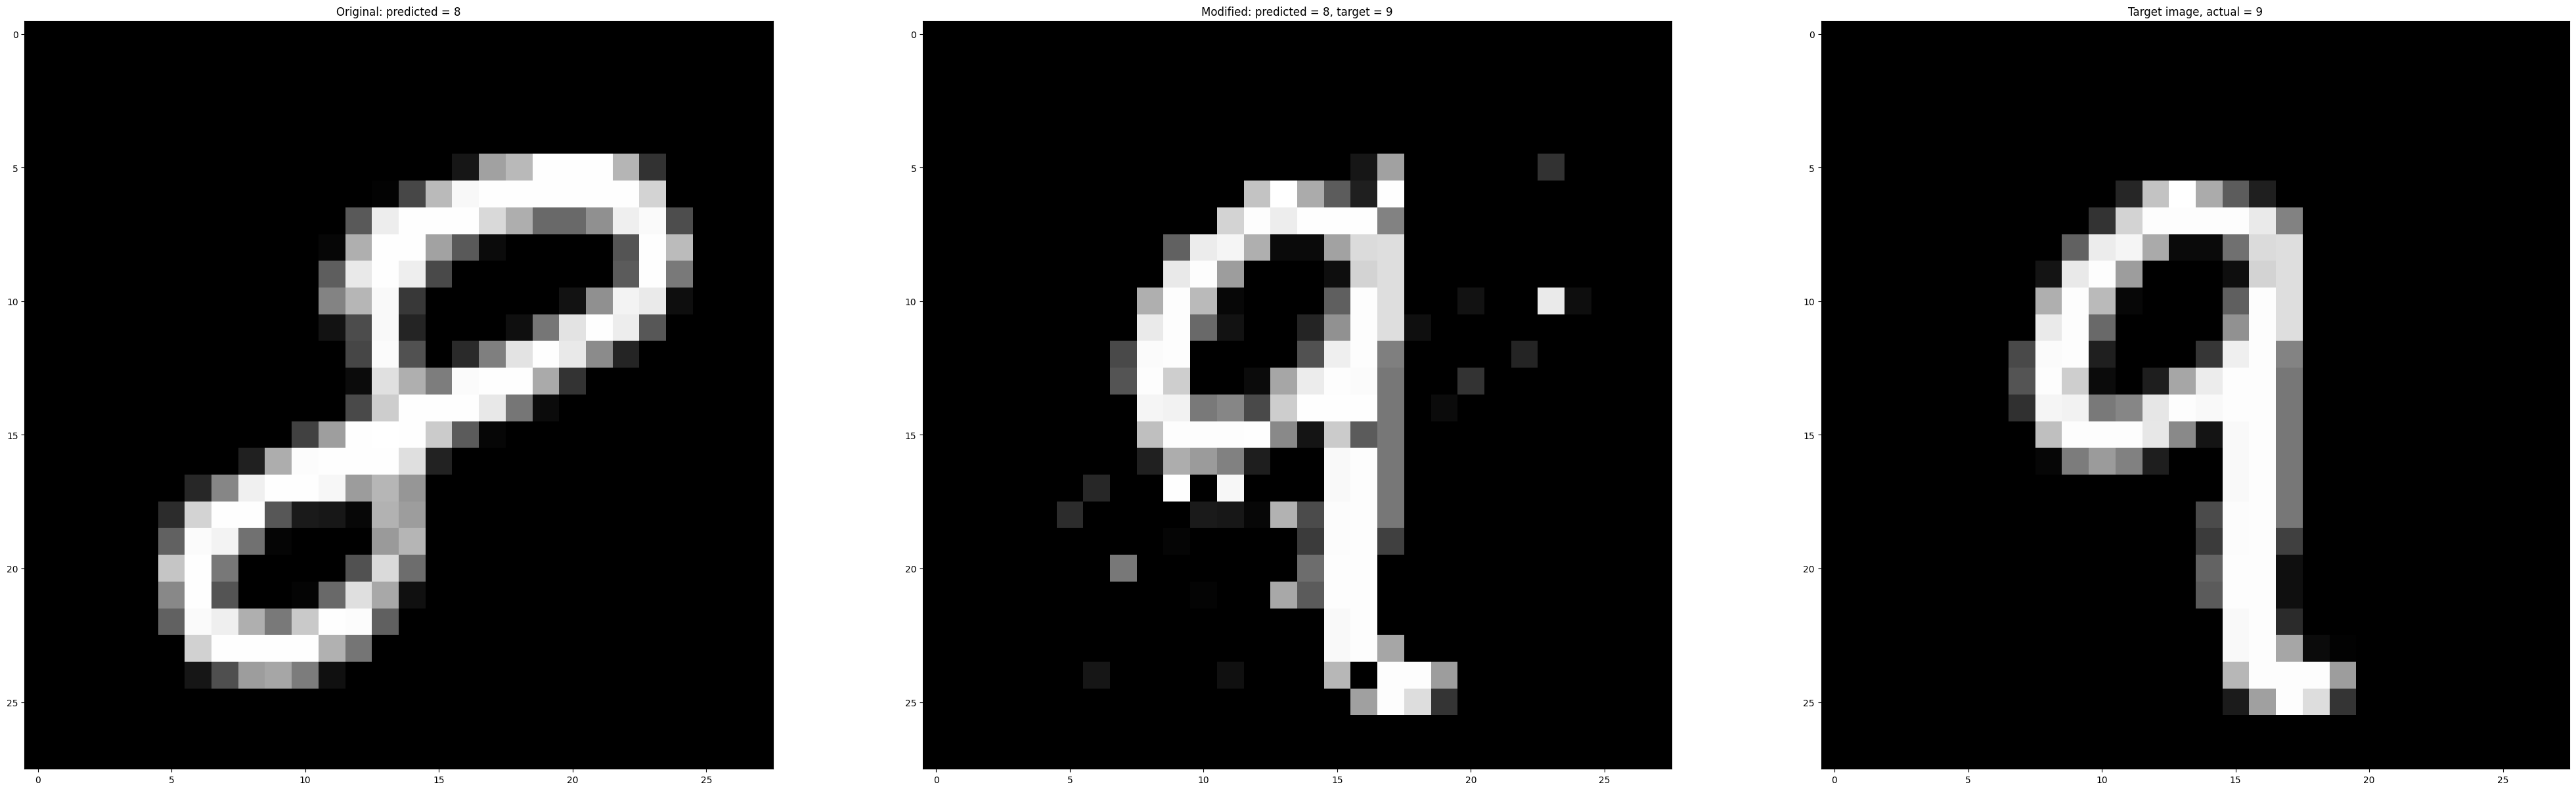

best dist 4.5399215984369015
ci_predicted:  6 target_actual: 8
initial ||I-T||:  10.357918441120804
best ||best-T||:  4.5399215984369015
||best-I||:  9.309972412040572
changed pixels:  149


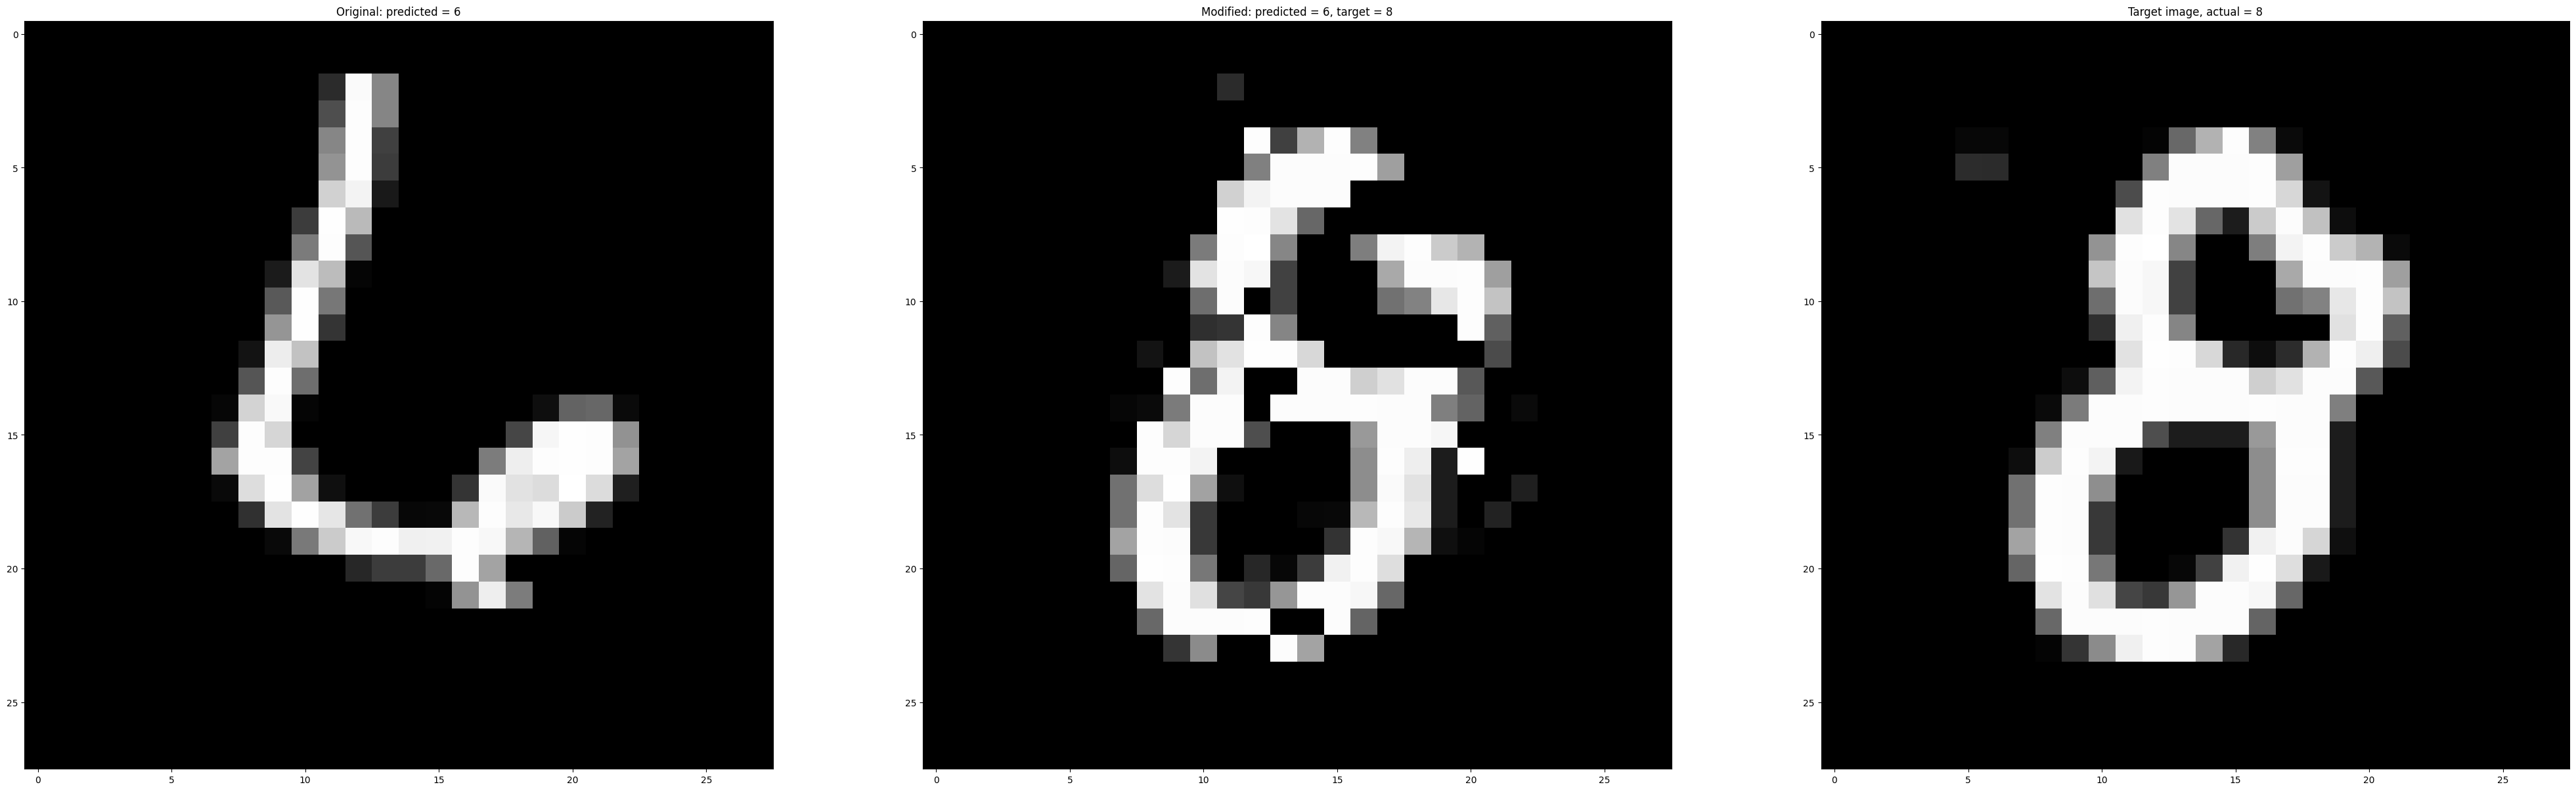

best dist 5.074799215918949
ci_predicted:  9 target_actual: 2
initial ||I-T||:  10.95309913325162
best ||best-T||:  5.074799215918949
||best-I||:  9.706533549158824
changed pixels:  165


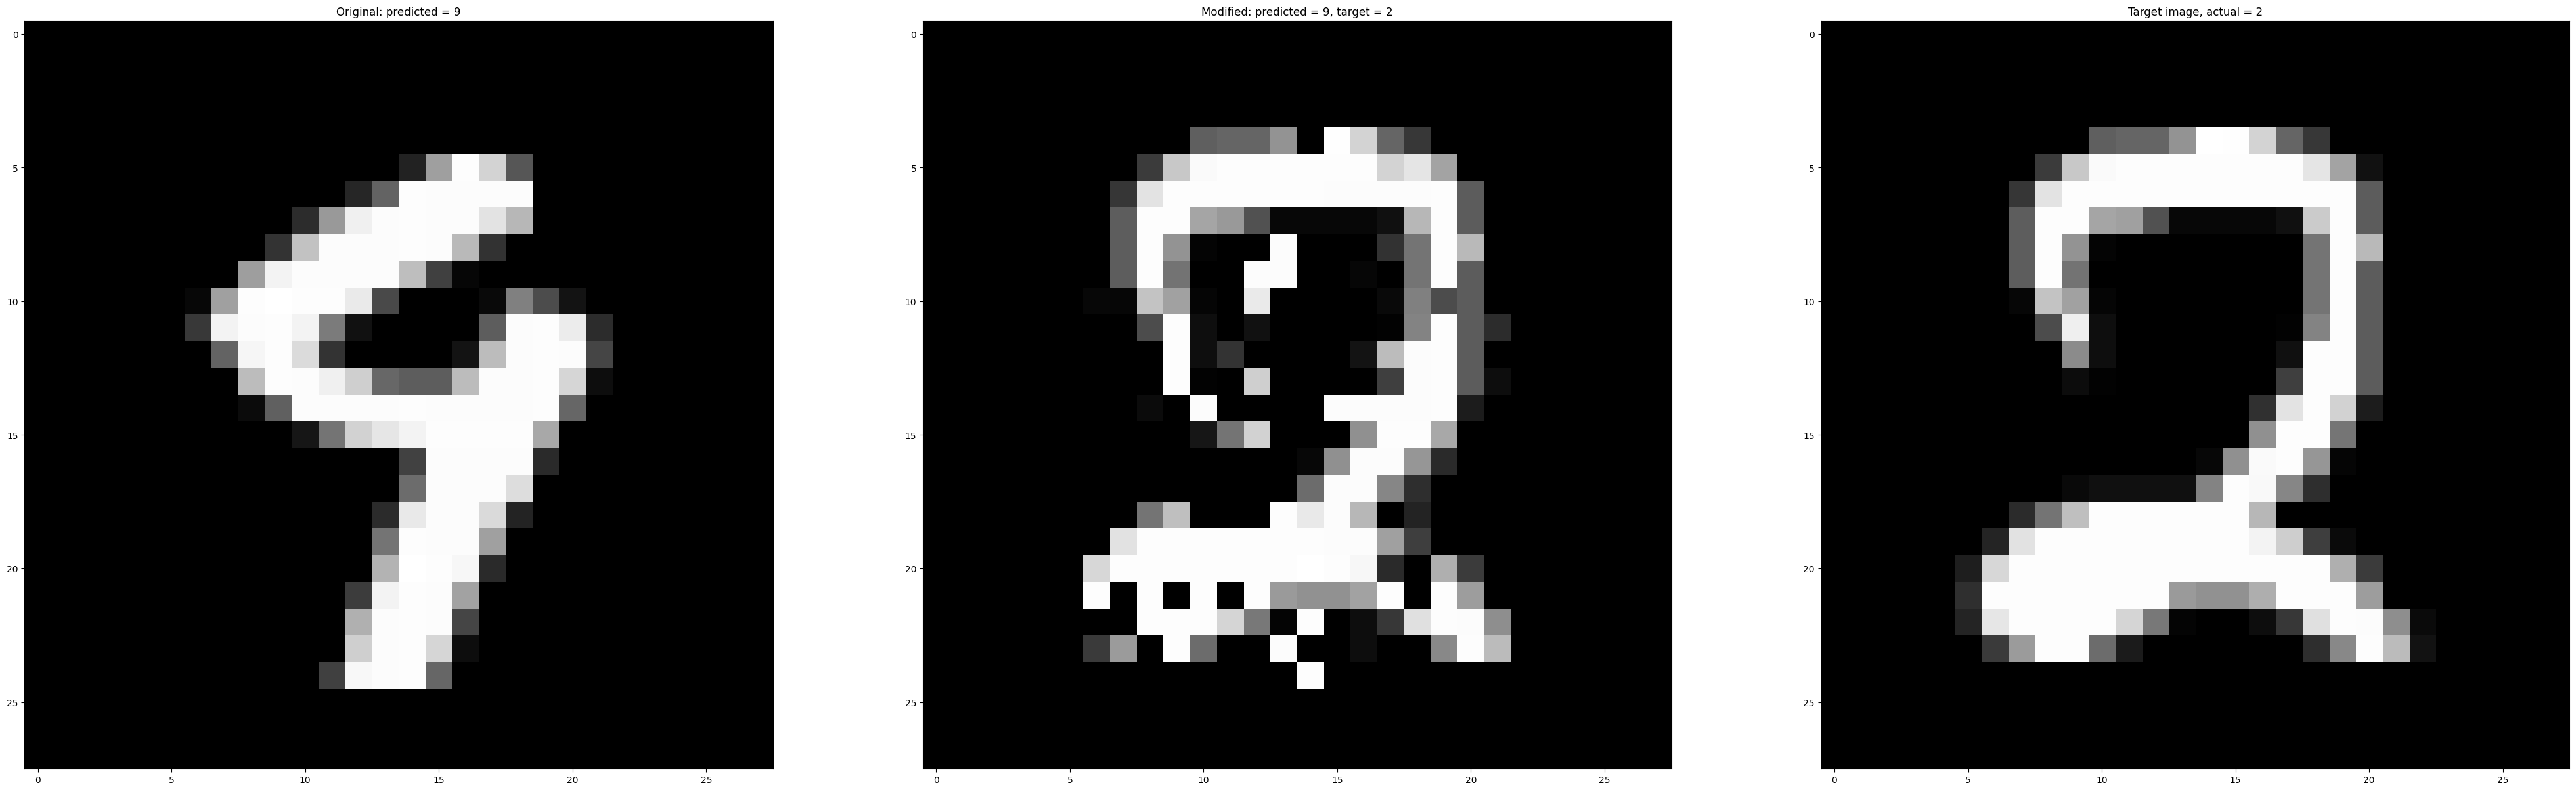

best dist 4.819759406669344
ci_predicted:  4 target_actual: 7
initial ||I-T||:  9.213436521387713
best ||best-T||:  4.819759406669344
||best-I||:  7.852218272275885
changed pixels:  110


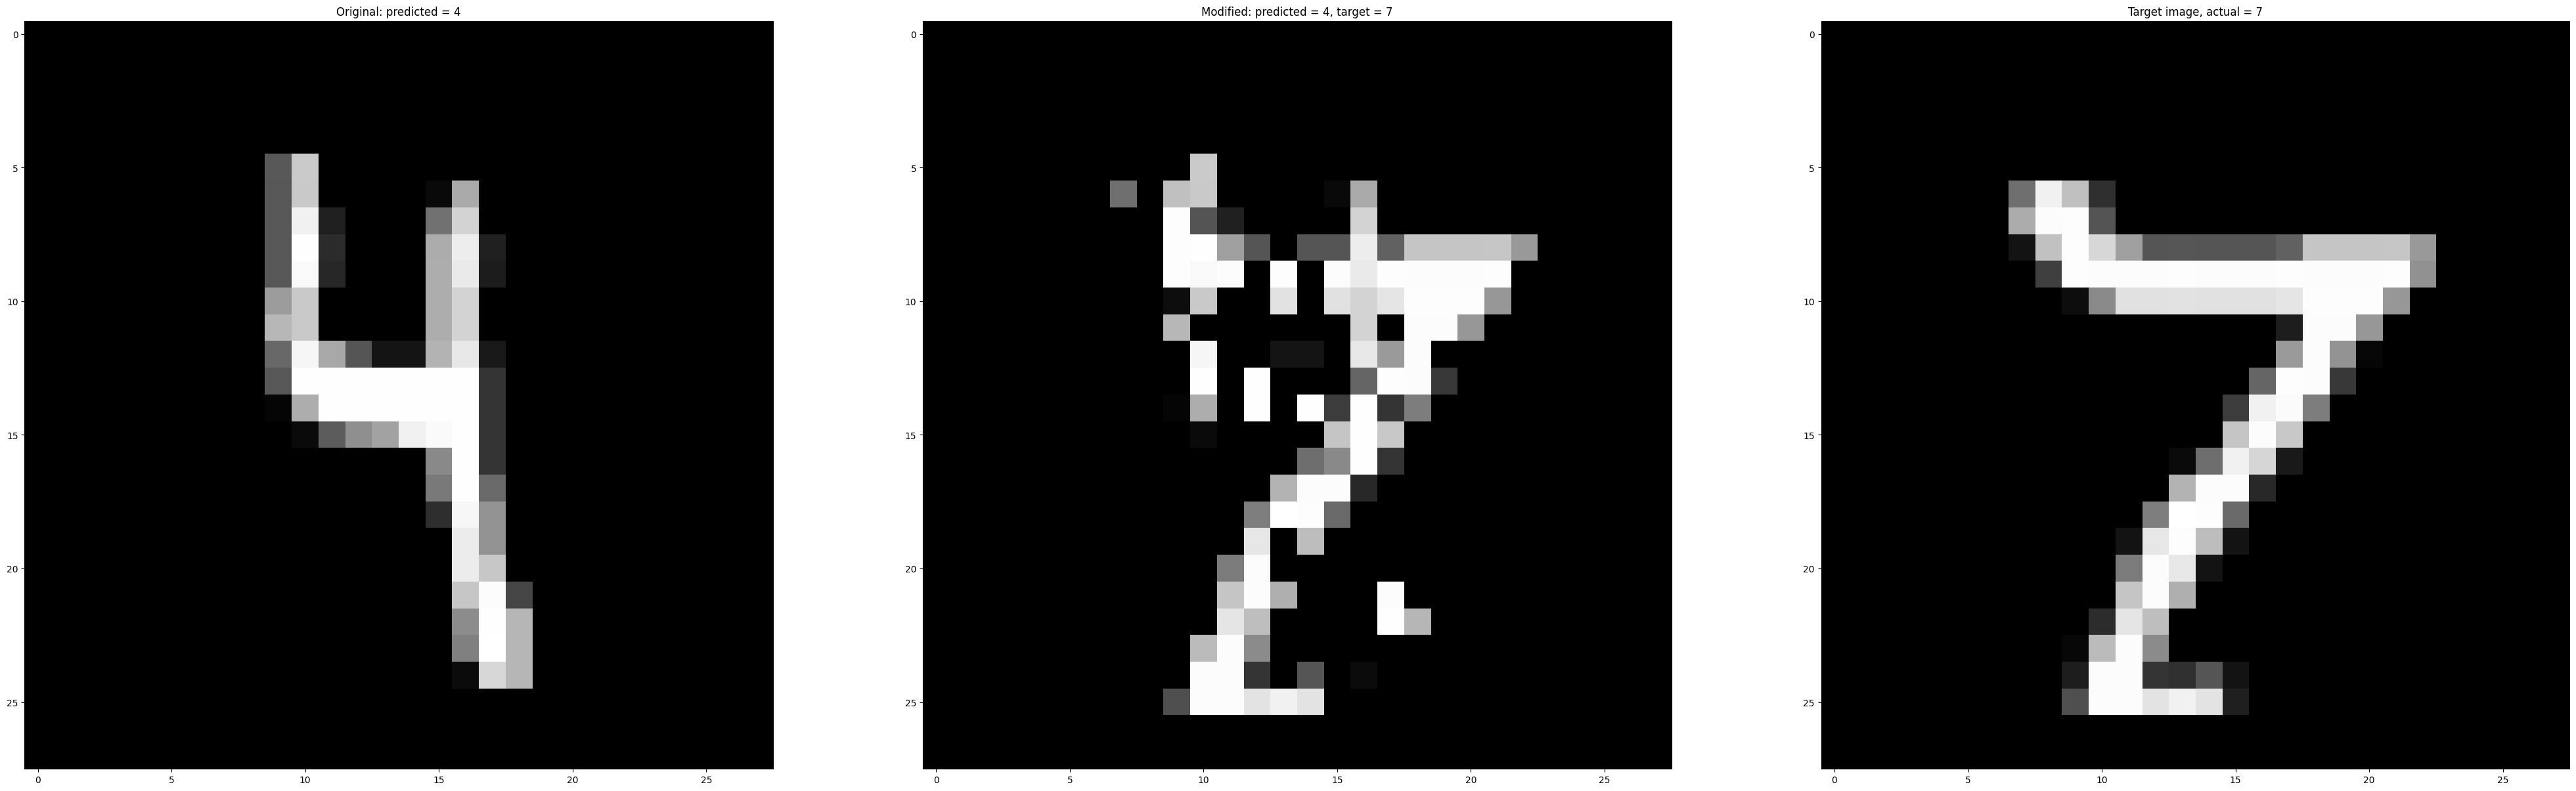

best dist 5.876531760200299
ci_predicted:  4 target_actual: 3
initial ||I-T||:  10.082204222482916
best ||best-T||:  5.876531760200299
||best-I||:  8.192509777547386
changed pixels:  131


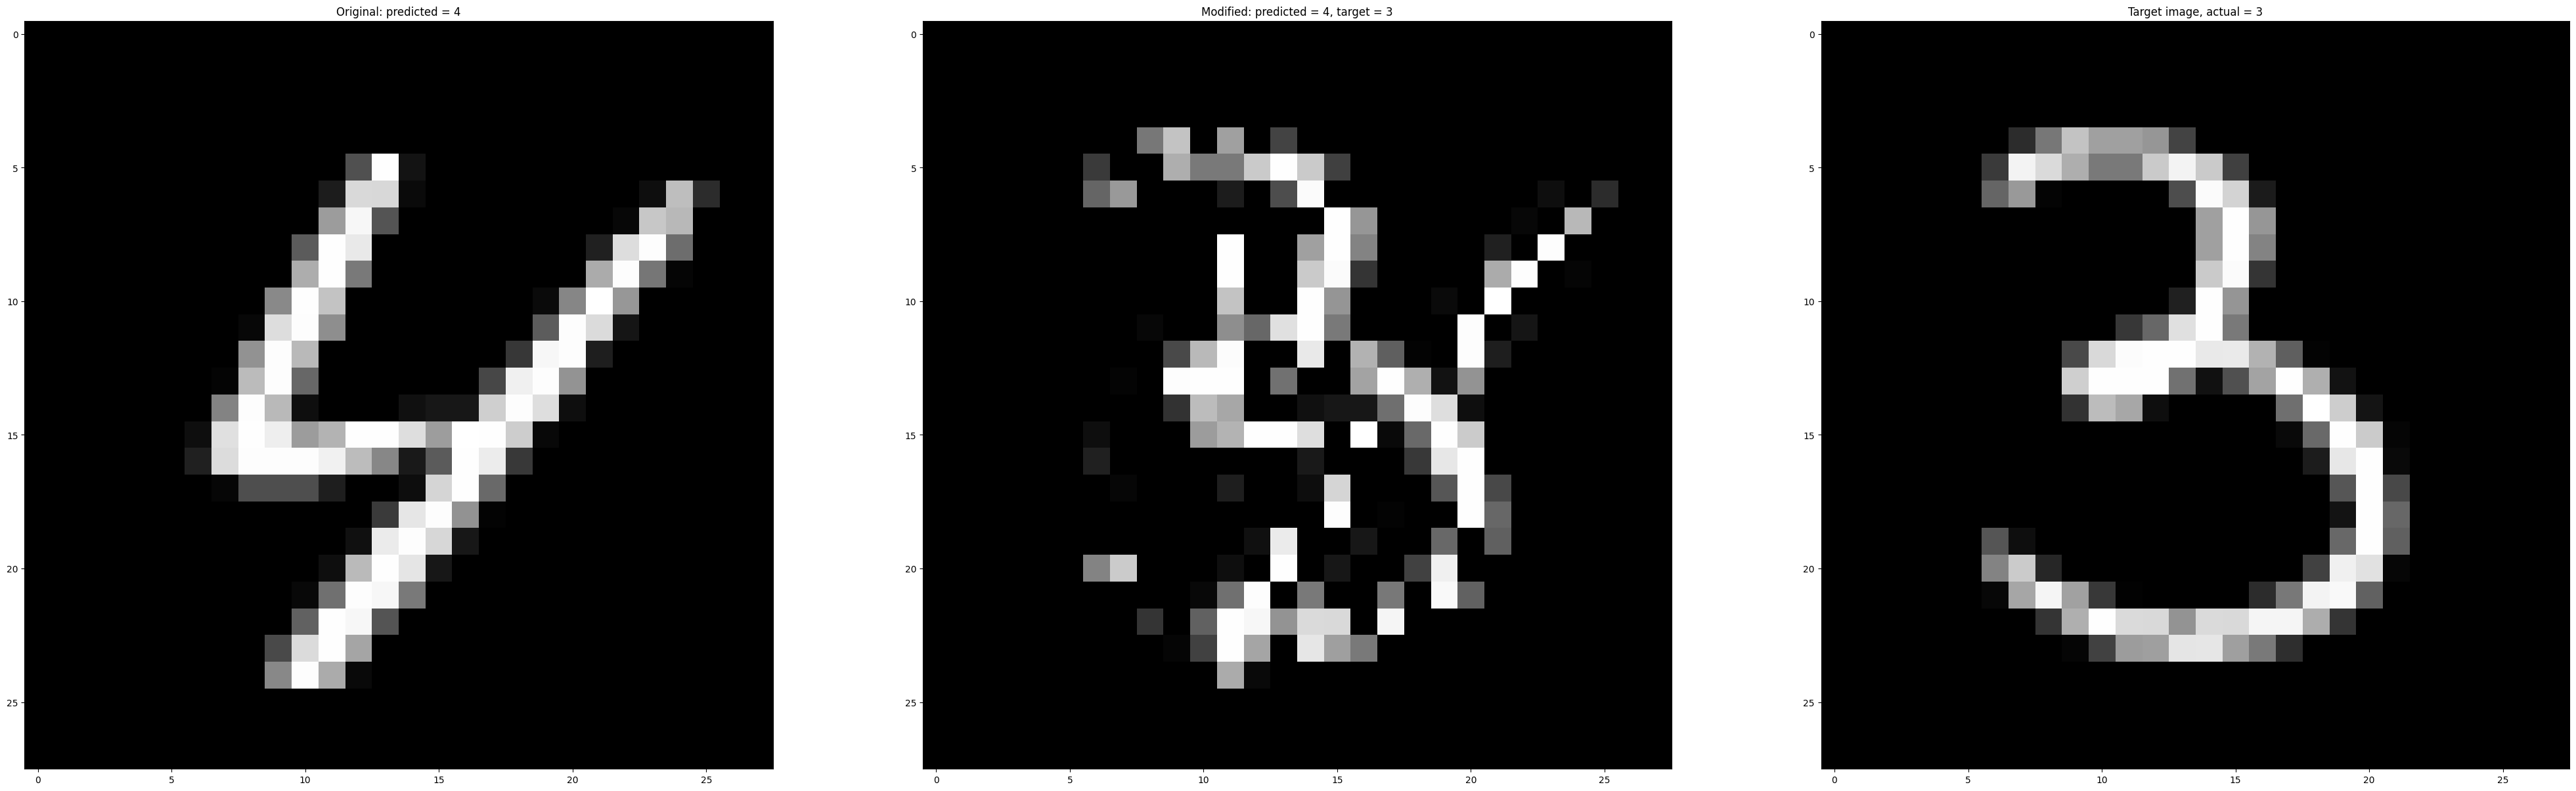

In [100]:
images_num = 3

for i in range(images_num):
    target_found = False
    while target_found == False:
        index = random.randint(0, len(x_test_extra)-1)
        pred, probs = predict(model, x_test_extra[index:index+1])
        if pred == y_test[index]:
            target_found = True

            target_indx = index
            target_actual = y_test[index]
            target_probabilities = probs
            target_image = x_test_extra[target_indx:target_indx+1]

    I_found = False
    while I_found == False:
        index = random.randint(0, len(x_test_extra)-1)
        pred, probs = predict(model, x_test_extra[index:index+1])
        if pred != target_actual:
            I_found = True

            ci = index
            ci_predicted = pred
            i_probabilities = probs
            ci_image = x_test_extra[index: index+1]


    number_of_pixels_edited = 50



    best_image, best_pred, best_dist, best_step, best_n, n = boundary_attack(ci_image, target_image, model, ci_predicted, number_of_pixels_edited)

    plt.figure(figsize = (50, 50))
    plt.subplot(1,3,1)
    plt.imshow(x_test_extra[ci][..., 0], cmap="gray")
    plt.title(f"Original: predicted = {ci_predicted}")
    plt.subplot(1,3,2)
    plt.imshow(best_image[0, ..., 0], cmap = "gray")
    plt.title(f"Modified: predicted = {best_pred}, target = {target_actual}")
    plt.subplot(1,3,3)
    plt.imshow(target_image[0,..., 0], cmap="gray")
    plt.title(f"Target image, actual = {target_actual}")


    plt.show()

White box attack
Fast gradietn sign method
Weights of CNN is not changed, but image is modified to maximize lost function (to make CNN as wrong as possible)
Use: x_adv = x + e * sign (\Delta_x J(\theta, x, y))
x= orig image, e = small parameter, J = loss function
gradient is taken with respect to the input pizels (determining which direction to follow in order to maximise error)

In [2]:
import torch
import random

torch.manual_seed(42)

In [115]:
#x_{adv} = x + epsilon * sign(grad)

pred = -1
actual = -2

def predict_tens(model, image):
    probabilities = model(image, training = False).numpy()[0]
    pred = int(np.argmax(probabilities))
    return pred, probabilities


while pred!= actual:
    picked_index = random.randint(0, len(x_test_extra)-1)


    image = x_test_extra[picked_index:picked_index+1]

    pred, probs = predict_tens(model, image)
    
    actual = y_test[picked_index]

image = x_test_extra[picked_index:picked_index+1]
image = tf.convert_to_tensor(image, dtype=tf.float32)

loss_func = tf.keras.losses.SparseCategoricalCrossentropy()

def attack(actual, model, image, epsilon):
    tensor_image = tf.convert_to_tensor(image, dtype=tf.float32)

    with tf.GradientTape() as tape:
        tape.watch(tensor_image)
        prob = model(tensor_image, training=False)
        y_true = tf.convert_to_tensor([int(actual)], dtype=tf.int32)
        loss = loss_func(y_true, prob)

    gradient = tape.gradient(loss, tensor_image)
    sign_grad = tf.sign(gradient)
    #x_{adv} = x + epsilon * sign(grad)
    x_adv = tf.clip_by_value(tensor_image + epsilon * sign_grad, 0, 1)
    pred_adv, probs_adv = predict_tens(model, x_adv)

    return x_adv, pred_adv, probs_adv

epsilon = 0.15

eps_list = [0.05, 0.1, 0.15, 0.2, 0.25, 0.3]
for eps in eps_list:
    x_adv, pred_adv, probs_adv = attack(actual, model, image, eps)
    print(eps, "pred_adv: ", pred_adv, "P(actual):", float(pr_adv[actual]))


plt.figure()

plt.subplot(1,3,1)
plt.imshow(image[0, ..., 0], cmap="gray")
plt.title(f"original: {pred}, actual: {actual}")

plt.subplot(1,3,2)
plt.imshow(x_adv[0, ..., 0], cmap="gray")
plt.title(f"pred= {pred_adv}")

plt.subplot(1,3,3)
plt.imshow((x_adv - image)[0, ..., 0], cmap = "seismic")
plt.title("Perturbation")
plt.show()


NameError: name 'p_adv' is not defined

In [93]:
def greedy_random_search(model, image, true_label, max_step = 10000):
    n  = 10

    x_old = image.copy()

    pred, probs = predict(model, image)

    old_prob = probs[true_label]

    step = 0

    pred_new = pred

    print(f"step is {step} and max_step is {max_step}")
    while pred_new == true_label and step < max_step:

        if step%100 == 0:
            print(step, old_prob)

        H, W = x_old.shape[1], x_old.shape[2]   # 28, 28
        x_coords = [random.randint(0, W-1) for _ in range(n)]
        y_coords = [random.randint(0, H-1) for _ in range(n)]


        salt_pepper = [random.randint(0, 1) for _ in range(n)]


        x_new = x_old.copy()

        for i in range(n):
            x_new[0, y_coords[i], x_coords[i], 0] = salt_pepper[i]
    
        pred, probs = predict(model, x_new)

        if probs[true_label] < old_prob:
            old_prob = probs[true_label]
            x_old = x_new.copy()
            pred_new = pred

        step += 1
    print(f"true label is {true_label} and prediction is {pred_new}")
    return x_old, pred_new





    

<class 'keras.src.models.sequential.Sequential'>
step is 0 and max_step is 10000
0 0.99996555
true label is 4 and prediction is 9


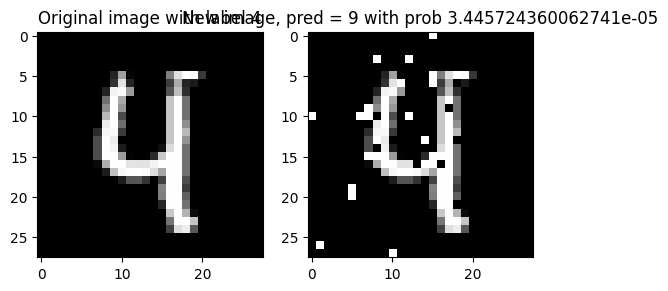

In [ ]:
#x_test_extra = x_test[..., None]     
#x_train_extra = x_train[..., None]  
#x_val_extra = x_val[..., None]
#pred = 0
#actual = np.inf
#while pred!= actual:
#    picked_index = random.randint(0, len(x_test_extra)-1)#

    #probs = model(x_test_extra[picked_index:picked_index+1]).numpy()[0]   # x_train[5:6] has shape (1,28,28,1)
    #pred = np.argmax(probs)
    
   # actual = y_test[picked_index]



#n  = 10

#x_original = x_test_extra[picked_index:picked_index+1].copy()

#def predict(model, image):
 #   probabilities = model(image, training = False).numpy()[0]
  #  pred = int(np.argmax(probabilities))
   # return pred, probabilities

#pred, probs = predict(model, x_test_extra[picked_index:picked_index+1])

#old_prob = probs[actual]

#
#pred_new = pred


#print(type(model))
#x_old, pred_new = greedy_random_search(model, x_original, actual)





#final_image = x_old
#starting_image = x_original
#final_predicted_class = pred_new
#final_probability = probs[final_predicted_class]

#plt.figure()
#plt.subplot(1,2,1)
#plt.imshow(x_original[0, ..., 0], cmap = "gray")
#plt.title(f"Original image with label {actual}")

#plt.subplot(1,2,2)
#plt.imshow(x_old[0, ..., 0], cmap = "gray")
#plt.title(f"New image, pred = {final_predicted_class} with prob {final_probability}")

#plt.show()


In [105]:

#Find image

for _ in range(10000):
    index = random.randint(0, len(x_test_extra)-1)
    pred, probs = predict(model, x_test_extra[index:index+1])
    if pred == y_test[index]:
        target_indx = index
        target_actual = y_test[index]
        target_probabilities = probs
        target_image = x_test_extra[target_indx: target_indx+1]
        break

for _ in range(100000):
    index = random.randint(0, len(x_test_extra)-1)
    pred, probs = predict(model, x_test_extra[index:index+1])
    if pred != target_actual and pred == y_test[index]:
        ci = index
        ci_predicted = pred
        i_probabilities = probs
        ci_image = x_test_extra[index]
        ci_actual = y_test[ci]
        break

number_of_pixels_edited = 50

ci_image = x_test_extra[index:index+1]
target = x_test_extra[target_indx:target_indx+1]
target_label = y_test[target_indx]


In [111]:

FSGM_image, FGSM_predict, _ = attack(target_label, model, target, epsilon)
print("FSGM image found")

FSGM image found


In [114]:
boundary_image, prediction, _, _, _, _ = boundary_attack(ci_image, target_image, model, ci_predicted, number_of_pixels_edited)
print("boundary image found")



#ci_image, target_image, model, ci_predicted, number_of_pixels_edited

best dist 3.6956930157400487
ci_predicted:  0 target_actual: 6
initial ||I-T||:  11.345535191485592
best ||best-T||:  3.6956930157400487
||best-I||:  10.726743304220914
changed pixels:  187
boundary image found


In [108]:
greedy_image, pred_greedy = greedy_random_search(model, target, target_label)
print("Greedy iamge found")

step is 0 and max_step is 10000
0 0.99999976
true label is 6 and prediction is 8
Greedy iamge found


hi
6
(1, 28, 28, 1)


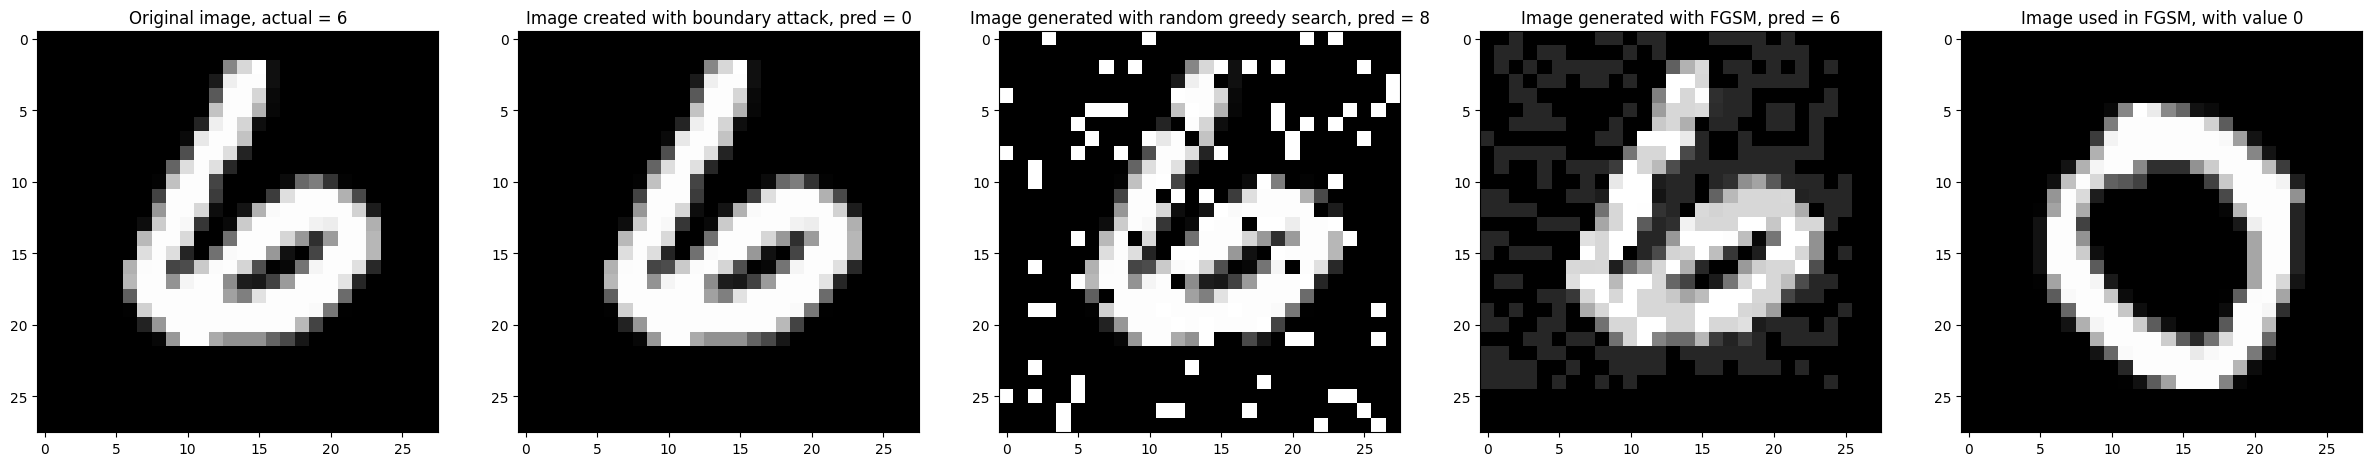

In [112]:


plt.figure(figsize=(30,30))
plt.subplot(1,5,1)
plt.imshow(target[0,..., 0], cmap = "gray")
plt.title("Original image, actual = " + str(target_label))

plt.subplot(1,5,2)
plt.imshow(boundary_image[0,..., 0], cmap = "gray")
plt.title("Image created with boundary attack, pred = " + str(prediction))

plt.subplot(1,5,3)
plt.imshow(greedy_image[0,..., 0], cmap= "gray")
plt.title("Image generated with random greedy search, pred = " + str(pred_greedy))

print("hi")
print(FGSM_predict)
plt.subplot(1,5,4)
print(FSGM_image.shape)
plt.imshow(FSGM_image[0,..., 0], cmap="gray")
plt.title("Image generated with FGSM, pred = " + str(FGSM_predict))

plt.subplot(1,5,5)
plt.imshow(x_test_extra[ci,:,:, 0], cmap="gray")
plt.title("Image used in FGSM, with value " + str(ci_actual))

plt.show()
